In [1]:
# from langchain_ollama import ChatOllama
# from langchain_core.tools import tool

# llm = ChatOllama(
#     model="llama3.1:8b"
# )

# response = llm.invoke("What is the capital of France?")
# print(response.content)

In [17]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from dotenv import load_dotenv
import os
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, ToolMessage

load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-flash-latest"
)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-latest', client=<google.genai.client.Client object at 0x000001EB62987B80>, default_metadata=(), model_kwargs={})

In [4]:
llm.invoke("What is the capital of France?")

AIMessage(content=[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'EqQBCqEBAb4+9vuamwfvmXAydr1I6qyQPYHYmw1nqxeGH9UAVGZmu+c7I8RET7VbCa9NwvW2KsA9j6BOs497j0zVMnIyQMRzq8dinxJKtMhkcI0Ag/swYEobfbVrFyZBM9zhDJ4IBCJ1S2i38+m05kiF9elokwmGEgT4F6YUeKVJsteyWcm4Dkr+Qp4MiYmChEKnxz5UbTrRk/R7l/wFluBK2PfmXV0='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d661b-b233-7363-985c-9443d8245563-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 35, 'total_tokens': 43, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}})

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun
@tool
def duck_search(query: str):
    """Use this tool to search for information on the web using DuckDuckGo."""
    search_tool = DuckDuckGoSearchRun()
    return search_tool.invoke(query)

In [6]:
from langchain_community.retrievers import ArxivRetriever

arxiv_retriever = ArxivRetriever(
    load_max_docs=2,
    get_full_documents=True
)

In [7]:
arxiv_retriever.invoke("Transformer architecture")

[Document(metadata={'Published': '2021-12-24', 'Title': 'Architectural Implications of Graph Neural Networks', 'Authors': 'Zhihui Zhang, Jingwen Leng, Lingxiao Ma, Youshan Miao, Chao Li, Minyi Guo', 'Summary': 'Graph neural networks (GNN) represent an emerging line of deep learning models that operate on graph structures. It is becoming more and more popular due to its high accuracy achieved in many graph-related tasks. However, GNN is not as well understood in the system and architecture community as its counterparts such as multi-layer perceptrons and convolutional neural networks. This work tries to introduce the GNN to our community. In contrast to prior work that only presents characterizations of GCNs, our work covers a large portion of the varieties for GNN workloads based on a general GNN description framework. By constructing the models on top of two widely-used libraries, we characterize the GNN computation at inference stage concerning general-purpose and application-specifi

In [8]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from sympy import deg

@tool
def arxiv_tool(name: str):
    """Use this tool to get information from Arxiv Database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(name)

In [9]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(name: str):
    """Use this tool to get information about a person from Wikipedia."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(name)


In [10]:
#Custom Tool
@tool
def personal_info(name: str):
    """Use this tool to get personal information about a person."""
    info = {
        "Virat Kohli": "Virat Kohli is an Indian cricketer and former captain of the Indian national team.",
        "Sachin Tendulkar": "Sachin Tendulkar is a former Indian cricketer and one of the greatest batsmen in the history of cricket."
    }
    return info.get(name, "Information not available.")

In [11]:
#Tool Binding
tools = [duck_search, arxiv_tool, wiki_tool, personal_info]

llm_with_tools = llm.bind_tools(tools)

In [12]:
llm_with_tools.invoke("Who is Virat Kohli?")

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duck_search', 'arguments': '{"query": "who is Virat Kohli"}'}, '__gemini_function_call_thought_signatures__': {'14d8dccc-a110-442f-b71c-a73bdbcc0547': 'Ep4CCpsCAb4+9vuaXz5TUhhw6b4RpCqFZO0CFkFUuqdMKYha/M7z1wVpugfbxXzQ4xr0NtB7FyVt18irmANTeJNDLfAfieib95UBQVF9Rn+hImtXRJdDY+DxlkQUB0fo7U0c8xxfasipb70HarI/2X33+oH9TCH7i6J9LU9XEHYY/sOqbzyNRPeB5RVuwM1IeqnzrvB//WV4I7H1l2RfJhoeS3zx4at7NscYUaDwiVOClye70mOdCI1aIHLCGzUiR48cYGfiZ5p1thaypA3sy55DxM/4uCSXMzLjTDtFvQc1QymcJ26/1uVFUZZ4rsLcRB+WeyGVNWf32Cwa+xRqahYSwXmIHFwNlPhyk3Z0GCkde1iHSkUQJrayJVFeGBBr/g=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d661c-1522-7891-993a-7e47b7da4fd5-0', tool_calls=[{'name': 'duck_search', 'args': {'query': 'who is Virat Kohli'}, 'id': '14d8dccc-a110-442f-b71c-a73bdbcc0547', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

In [14]:
#LangGraph Creation
from typing import TypedDict,List

class graph_schema(TypedDict):
    messages: List

In [16]:
def llm_node(state:graph_schema)->graph_schema:
    messages = state['messages']
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that use tools to answer the questions."),
            ("human", "{input}")
        ]
    )

    chain = prompt | llm_with_tools
    response = chain.invoke({"input": messages})

    state['messages'] = messages + [response]

    return state

In [33]:
# from langgraph.prebuilt import ToolNode
def tool_node(state:graph_schema)->graph_schema:
    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}


    tool_results = []

    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content = observation, tool_call_id=tool_call["id"]))

    state['messages'] = messages + tool_results

In [34]:
#Create a conditional edge between LLM_Node and Tool_Node

def if_tool_calls(state:graph_schema)->str:
    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

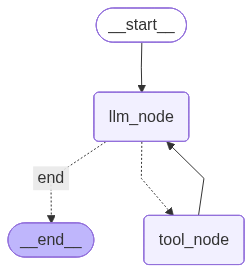

In [35]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node",llm_node)
graph.add_node("tool_node",tool_node)


#Edges between nodes
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node",if_tool_calls, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

react_graph = graph.compile()

from IPython.display import Image, display

Image(react_graph.get_graph().draw_mermaid_png())

In [36]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duck_search', 'arguments': '{"query": "latest AI news June 2024"}'}, '__gemini_function_call_thought_signatures__': {'cbfeed6a-5115-4b01-af0c-4802cc4cdc9a': 'EtUCCtICAb4+9vu0aU7T5euX83btN6C0fhnULJvHQxB5OLc4e/8pUo4Ha4qTPMUgdS7NXS31P1HtDAIYG8h8S0sTpqJ/UZ9E3ugYQjWaeKF3ECzTMslAWmoTyajZ65/qN3PVPxta2qadr7DWXmzyy52wez2piGSMgdlQ3z8AFmq9b5v+Xc3gBzLcZaZKsT762w7FknQvL3VhOcnZdnLNB+iUq0+g2y00i0W/Hu1Qm87Lyf7VLTJ4ZxH2LN/jz9Nu+5OFvbeK/EfeS+G21Yiv7bChcJ/jtZE96R1qQUYfVB+RIAKfgahyQO0C22AlYlvFG9VCt/xcaWlFfKHchGOrWdoTcAkWOfxaDPbJ4GfpK5pjh7/qlQHMpp6m2EXHkDCipqA7/q+BSN8JeFQsE4r9tsb6K7/Oykq/LnpIpNM0GCZgWG+jPTAuYQAyK8XYt0C5PSoinIGVPHw='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d6636-c59c-7570-8b51-4ae9ce9ec3ca-0',

In [37]:
for chunk in react_graph.stream(
    {"messages": [HumanMessage(content="What is the latest news on AI?")]},
    stream_mode="updates"
):
    print(chunk)

{'llm_node': {'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duck_search', 'arguments': '{"query": "latest news on AI October 2023"}'}, '__gemini_function_call_thought_signatures__': {'5b44a203-a69e-4810-a7b6-fa175098eac6': 'Eo4CCosCAb4+9vs8Rs9FaOi+uGXfzX+bwgbueM33ZA8YXg6+0ZYa3e17OcXHO2m5aoOfxnh7tFDPVARNUvZNdO8a0/hqbMT+t0KUhkN7sLFsGshDx1r55XtOHT7TTd9HVTv3MARvzA3PSChnRGr0O4galyyCc3vZTLbWgmV2TwOmtfNwCLImQDlFHNfI4OHlsI0C2/oTHpcYxN+8HoCjGhakjDUmdhym5SBy3DqvS4GkRomeFBN7PiGXtjZS2X91rpyLghkU9d0WO3MkRVvwMVvuvISwXeC/VuMzkTJnjkWkeWGStaD6wj5KyefZsD3IC3oV3JS6PTZf8p2xXUuflWzF2AbPUT8hHJqoaOL8gqBj'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d6638-bb81-7bf1-bc5f-3405f689cbbc-0', tool_calls=[{'name': 'duck_search', 'args': {'query': 'latest news on AI Octob